# Quality control of automatic snow water equivalent (SWE)

This notebook documents the SWE cleaning applied to daily records from DGA automatic stations used in the UPLA / Glacies communication on the 2026 El Niño austral-winter snowpack (Central Chilean Andes). It reproduces the SWE component of the processing pipeline; snow depth (SD) alignment and site-specific rules that require SD are described separately in the main project repository (`cleaning_script/`).

Input fields are the daily minimum, mean, and maximum SWE (`min`, `media`, `max`, mm). Parameter values are listed in `QC_PARAMETERS.csv`.


## Data and example files

Five stations with automatic SWE are considered: Quebrada Larga, Portillo, Laguna Negra, Termas del Flaco, and Lo Aguirre (DGA identifiers in the configuration cell below).

The folder `example_data/` contains **unprocessed** SWE exports (as retrieved from DGA) for **Quebrada Larga** and **Portillo**, so that the notebook can be run without the full `ElNiño_2026` dataset. **Portillo** (05401007) is the default worked example: the pillow sensor record contains more isolated spikes and uses the station-specific MAD parameters in `QC_PARAMETERS.csv`. Cleaned results are written only to `qc_outputs/`; the bundled CSVs are not modified. When the directory `Data/Station_SWE/` is present at the project root, the same code reads those files and, after a one-time backup, may overwrite them with cleaned values.


## Processing sequence

For each SWE column present, the following steps are applied in order:

1. **Physical bounds.** Negative values are set to zero. Values above a station maximum (`max_swe_mm` in `QC_PARAMETERS.csv`) are set to missing.
2. **Isolated spikes.** A robust median/MAD filter on a centred 7-day window (`fwindow = 3`) flags one-day outliers. A point is removed if it exceeds the MAD-based threshold `k` and is inconsistent with its neighbours, or if both daily increments exceed an absolute threshold (`abs_thr_mm`). Flagged values are set to missing.
3. **Gap filling and smoothing.** Missing segments of up to two days are linearly interpolated, then a centred rolling median (`smooth_window` days) is applied. Values are clipped to non-negative SWE again.

Portillo (pillow sensor) uses tighter MAD settings and a longer smooth window; see the station table below.


## Paths, run options, and station parameters

Set `station_id` to a DGA code to process one station, or to `None` to process every station for which a CSV exists in the SWE directory. In example mode, cleaned output is written only to `qc_outputs/` so that the bundled example files are not modified.


In [23]:
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

here = Path.cwd().resolve()
if (here / "snow_qc_github" / "example_data").is_dir():
    here = here / "snow_qc_github"
elif (here.parent / "snow_qc_github" / "example_data").is_dir():
    here = here.parent / "snow_qc_github"

full_project = (here.parent / "Data" / "Station_SWE").is_dir()
example = (here / "example_data").is_dir() and any((here / "example_data").glob("*_SWE.csv"))

if example:
    swe_dir = here / "example_data"
    backup_dir = swe_dir / "_backup"
    out_dir = here / "qc_outputs"
    write_back = False
else:
    root = here.parent if full_project else here.parent
    swe_dir = root / "Data" / "Station_SWE"
    backup_dir = swe_dir / "_original_backup"
    out_dir = here / "qc_outputs"
    write_back = True

out_dir.mkdir(parents=True, exist_ok=True)

station_id = "05401007" if example else None  # Portillo (default example)

mad_default = dict(fwindow=3, k=4.0, abs_thr=100.0, smooth=3)

stations = {
    "04520006": dict(name="Quebrada Larga", file="QUEBRADA_LARGA_SWE.csv", max_mm=3500.0),
    "05401007": dict(
        name="Portillo", file="PORTILLO_SWE.csv", max_mm=1200.0,
        mad=dict(fwindow=3, k=3.5, abs_thr=75.0, smooth=9),
    ),
    "05703009": dict(name="Laguna Negra", file="LAGUNA_NEGRA_SWE.csv", max_mm=3000.0),
    "06020001": dict(name="Termas del Flaco", file="TERMAS_DEL_FLACO_SWE.csv", max_mm=1200.0),
    "07301000": dict(name="Lo Aguirre", file="LO_AGUIRRE_SWE.csv", max_mm=1200.0),
}

print("Using example_data/" if example else f"SWE directory: {swe_dir}")


Using example_data/


## Algorithm (SWE columns)

The functions below implement steps 1–3. Spike detection follows the same logic as in the project scripts: for each day, the local median and median absolute deviation are computed on a window of length `2 × fwindow + 1` days.


In [24]:
cols = ("min", "media", "max")


def mad_spikes(df, use_cols, fwindow=3, k=4.0, abs_thr=100.0):
    out = df.copy()
    nflag = pd.DataFrame(0, index=out.index, columns=use_cols, dtype="int8")
    w = 2 * fwindow + 1
    for c in use_cols:
        s = out[c].astype(float)
        med = s.rolling(w, center=True).median()
        mad = (s - med).abs().rolling(w, center=True).median().replace(0, np.nan)
        z = (s - med).abs() / mad
        d1 = (s - s.shift(1)).abs()
        d2 = (s - s.shift(-1)).abs()
        nb = (s.shift(1) - s.shift(-1)).abs()
        hit = (
            (mad > 0) & (z > k)
            & (d1.fillna(np.inf) > k * mad) & (d2.fillna(np.inf) > k * mad)
            & (nb.fillna(0) < k * mad)
        ) | ((d1 > abs_thr) & (d2 > abs_thr))
        out.loc[hit, c] = np.nan
        nflag.loc[hit, c] = 1
    return out, nflag


def clean_swe(df, max_mm, **mad_kw):
    smooth = mad_kw.pop("smooth", 3)
    x = df.copy()
    for c in cols:
        if c not in x.columns:
            raise ValueError(f"missing column {c}")
    active = [c for c in cols if x[c].notna().any()]
    if not active:
        return x, {c: 0 for c in cols}
    for c in active:
        s = pd.to_numeric(x[c], errors="coerce").clip(lower=0)
        s = s.where(s <= max_mm)
        x[c] = s
    x, fl = mad_spikes(x, active, **mad_kw)
    for c in active:
        s = x[c].astype(float)
        s = s.interpolate(limit=2, limit_direction="both")
        s = s.rolling(smooth, center=True, min_periods=1).median()
        x[c] = s.clip(lower=0)
    return x, {c: int(fl[c].sum()) for c in cols}


## Run cleaning

In production mode, each station file is copied once to `_original_backup/` before the first clean; later runs read from that backup so that smoothing is not applied twice. In example mode, input is always read from `example_data/` (the committed raw files). The table reports the number of spike flags per column.


In [25]:
def backup_once(path):
    backup_dir.mkdir(parents=True, exist_ok=True)
    dest = backup_dir / path.name
    if not dest.exists():
        shutil.copy2(path, dest)
    return dest if dest.exists() else path


def raw_input_path(meta):
    path = swe_dir / meta["file"]
    if example:
        return path
    backup_once(path)
    bak = backup_dir / meta["file"]
    return bak if bak.is_file() else path


def run_one(sid, meta):
    path = swe_dir / meta["file"]
    if not path.is_file():
        return dict(station=sid, name=meta["name"], error="file not found")
    raw = pd.read_csv(raw_input_path(meta), parse_dates=["date"])
    kw = {**mad_default, **meta.get("mad", {})}
    kw = dict(fwindow=kw["fwindow"], k=kw["k"], abs_thr=kw["abs_thr"], smooth=kw["smooth"])
    cleaned, n_spike = clean_swe(raw, meta["max_mm"], **kw)
    out_path = out_dir / meta["file"]
    cleaned.to_csv(out_path, index=False, date_format="%Y-%m-%d")
    if write_back:
        cleaned.to_csv(path, index=False, date_format="%Y-%m-%d")
    return dict(station=sid, name=meta["name"], spikes=n_spike, out=str(out_path))


if station_id:
    todo = [station_id]
else:
    todo = [s for s, m in stations.items() if (swe_dir / m["file"]).is_file()]

rows = []
for sid in todo:
    print(stations[sid]["name"], sid)
    rows.append(run_one(sid, stations[sid]))

summary = pd.DataFrame(rows)
summary


Quebrada Larga 04520006


,station,name,spikes,out
0,04520006,Quebrada Larga,"{'min': 2, 'media': 21, 'max': 41}",/home/javier_medina/02_Work/02_Research/ElNiño...


## Diagnostic figure (optional)

Comparison of the mean SWE series (`media`) before and after cleaning for the selected station. In example mode, the pre-QC series is the file in `example_data/`; in production mode, it is the one-time backup under `_original_backup/`.


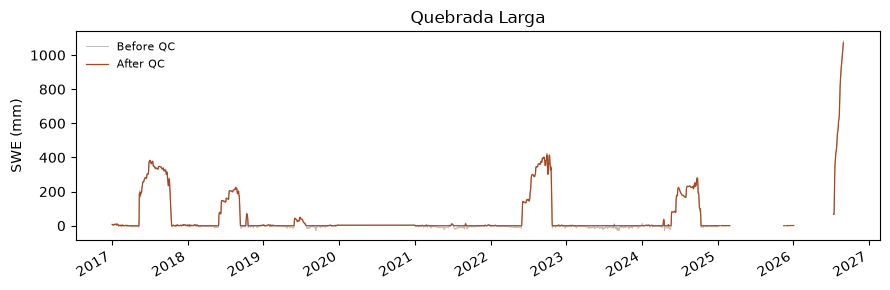

In [26]:
import matplotlib.pyplot as plt

sid = station_id or todo[0]
meta = stations[sid]
raw = pd.read_csv(raw_input_path(meta), parse_dates=["date"])
qc = pd.read_csv(out_dir / meta["file"], parse_dates=["date"])

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(raw["date"], raw["media"], color="#bbbbbb", lw=0.7, label="Before QC")
ax.plot(qc["date"], qc["media"], color="#a84820", lw=0.9, label="After QC")
ax.set_ylabel("SWE (mm)")
ax.set_title(meta["name"])
ax.legend(frameon=False, fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
plt.close(fig)


## Notes

Additional processing in the full study includes aligning SWE with snow depth (zero SWE when a rolling maximum of SD falls below 2 cm), Laguna Negra SD quality control, and Quebrada Larga pillow SWE checks against collocated SD in 2026. Those steps are not executed in this notebook; see `QC_PARAMETERS.csv` and `cleaning_script/README.md` in the `ElNiño_2026` repository.
